First 5 rows:
    Year      Status  Life expectancy  Adult Mortality  infant deaths  Alcohol  \
0  2015  Developing             65.0            263.0             62     0.01   
1  2014  Developing             59.9            271.0             64     0.01   
2  2013  Developing             59.9            268.0             66     0.01   
3  2012  Developing             59.5            272.0             69     0.01   
4  2011  Developing             59.2            275.0             71     0.01   

   percentage expenditure  Hepatitis B  Measles   BMI  ...  Polio  \
0               71.279624         65.0     1154  19.1  ...    6.0   
1               73.523582         62.0      492  18.6  ...   58.0   
2               73.219243         64.0      430  18.1  ...   62.0   
3               78.184215         67.0     2787  17.6  ...   67.0   
4                7.097109         68.0     3013  17.2  ...   68.0   

   Total expenditure  Diphtheria  HIV/AIDS         GDP  Population  \
0            

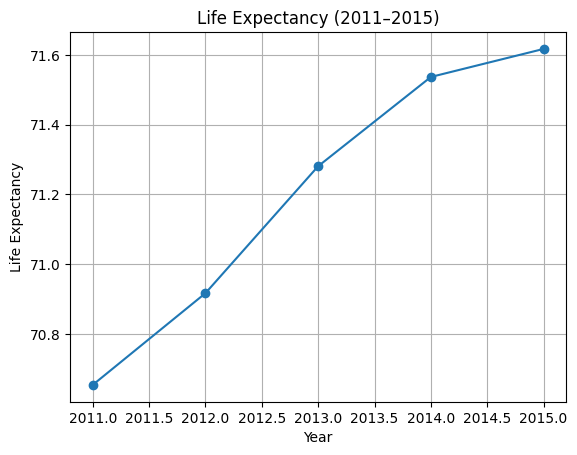

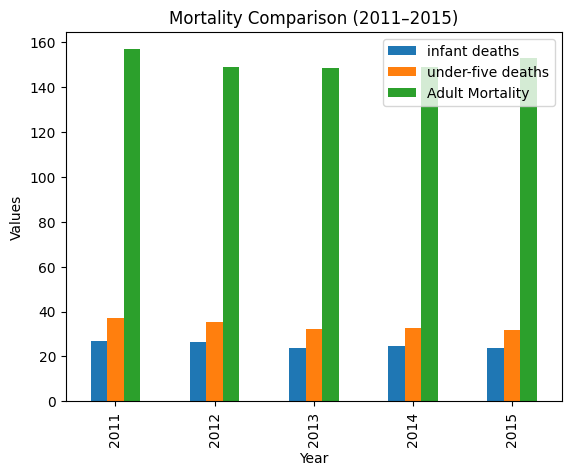


Correlation with Life Expectancy:

Life expectancy                    1.000000
Schooling                          0.713054
Adult Mortality                    0.696390
Income composition of resources    0.688662
BMI                                0.556901
HIV/AIDS                           0.556703
Status_Developing                  0.481415
Status_Developed                   0.481415
Diphtheria                         0.472211
thinness  1-19 years               0.468002
thinness 5-9 years                 0.462473
Polio                              0.458399
Alcohol                            0.388918
percentage expenditure             0.381418
under-five deaths                  0.222738
Total expenditure                  0.208844
infant deaths                      0.196769
Year                               0.170819
Hepatitis B                        0.170219
Measles                            0.157767
Name: Life expectancy, dtype: float64

Least correlated: Index(['Year', 'Hepatitis B

In [29]:

import pandas as pd
import matplotlib.pyplot as plt

# a.
df = pd.read_csv("data.csv")

# Fix column names
df.columns = df.columns.str.strip()

# b, c, d 
print("First 5 rows:\n", df.head())
print("\nInfo:\n")
df.info()
print("\nDescribe:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())

# e
df = df.drop(columns=['Population', 'GDP'])

# f
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())
# Categorical
cat_cols = df.select_dtypes(include=['str']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    
# g, h, i, j 
print("\nShape:", df.shape)
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("New Shape:", df.shape)
df_clean = df.copy()

# k
print("\nNumerical Columns:\n", num_cols)

# l
df_ml = df.copy()
for col in num_cols:
    mean = df_ml[col].mean()
    std = df_ml[col].std()
    if std != 0:
        df_ml[col] = (df_ml[col] - mean) / std
print("\nScaling applied")

# m
cat_cols = df_ml.select_dtypes(include=['str']).columns
print("\nCategorical Columns:\n", cat_cols)

# n
df_ml = pd.get_dummies(df_ml, columns=cat_cols)
print("\nAfter Encoding Columns:\n", df_ml.columns)

# o
df_clean['Year'] = pd.to_numeric(df_clean['Year'])
df_clean['Life expectancy'] = pd.to_numeric(df_clean['Life expectancy'])
df_year = df_clean[df_clean['Year'].between(2011, 2015)]
yearly_avg = df_year.groupby('Year')['Life expectancy'].mean()
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.title("Life Expectancy (2011–2015)")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.grid()
plt.show()

# p
cols = ['infant deaths', 'under-five deaths', 'Adult Mortality']
for col in cols:
    df_clean[col] = pd.to_numeric(df_clean[col])
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
grouped = df_year.groupby('Year')[cols].mean()
grouped.plot(kind='bar')
plt.title("Mortality Comparison (2011–2015)")
plt.xlabel("Year")
plt.ylabel("Values")
plt.show()

# q
corr = df_ml.corr()
print("\nCorrelation with Life Expectancy:\n")
corr_target = corr['Life expectancy'].abs().sort_values(ascending=False)
print(corr_target)
least = corr_target.tail(3).index
print("\nLeast correlated:", least)
df_ml = df_ml.drop(columns=least)
    
# r
df_ml.to_csv("cleaned_data.csv")



In [15]:
import pandas as pd

# Given dataset
data = {
'Age': ['25', '30', '35', '40', '45'],
'Income': ['$1000.5', '$1500.0', '$2000.75', '?', '$3000.25'],
'Signup_Date': ['2023-01-15', '2023-02-20', '2023-03-25', '2023-04-30', '2023-05-05'],
'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue'],
'Score': [85, 90, 78, 92, 88]
}

df = pd.DataFrame(data)

# before conversion
print("Before Conversion:\n")
print(df.dtypes)

# Cleaning Income
df['Income'] = df['Income'].replace('?', None)
df['Income'] = df['Income'].str.replace('$','', regex=False)
#convert in to 
df['Income'] = pd.to_numeric(df['Income'])

# Convert Age
df['Age'] = pd.to_numeric(df['Age'])

# Convert Date
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])

# Convert Color to category
df['Color'] = df['Color'].astype('category')

#  new types conversion
print("\nAfter Conversion:\n")
print(df.dtypes)

# Final clean
print("\nCleaned Data:\n")
print(df)

Before Conversion:

Age              str
Income           str
Signup_Date      str
Color            str
Score          int64
dtype: object

After Conversion:

Age                     int64
Income                float64
Signup_Date    datetime64[us]
Color                category
Score                   int64
dtype: object

Cleaned Data:

   Age   Income Signup_Date  Color  Score
0   25  1000.50  2023-01-15    Red     85
1   30  1500.00  2023-02-20   Blue     90
2   35  2000.75  2023-03-25  Green     78
3   40      NaN  2023-04-30    Red     92
4   45  3000.25  2023-05-05   Blue     88
